# P08 - Naive Bayes Classifier for Fake News Recognition

**Advanced Statistics for Physics Analysis – A.A. 2022/23**

## Introduction

Fake news are defined by the New York Times as *“a made-up story with an intention to deceive”*, aiming to confuse or mislead readers. In today's digital era, they spread rapidly across social media and other online platforms. Identifying and filtering fake news is one of the major challenges in modern journalism.

Naive Bayes classifiers are probabilistic models well-suited for text classification tasks. In this project, we will implement a **Multinomial Naive Bayes classifier in R** to classify social media posts as real or fake news.

## Project Goals

- Implement a **Multinomial Naive Bayes classifier** in R.
- Evaluate its performance on a dataset of social media posts.
- Apply the trained model to a second dataset with binary labels and compare results.

## Dataset Information

The suggested dataset is available on Kaggle [[2]](#references):

- **Training set**: 10,240 instances
- **Test set**: 1,267 instances

Suggested labels for classification:

| Label         | Class |
|---------------|-------|
| True          | 5     |
| Not-Known     | 4     |
| Mostly-True   | 3     |
| Half-True     | 2     |
| False         | 1     |
| Barely-True   | 0     |

## Steps

1. **Split the dataset** into training, validation, and test sets.
2. **Tokenization**:
   - Convert all text to lowercase.
   - Split text into tokens (words).
3. **Text Cleaning**:
   - Remove stop words (commonly used words with little meaning).
4. **Token Normalization**:
   - Create equivalence classes to group similar tokens (e.g., stemming or lemmatization).
5. **Vocabulary Building & Feature Selection**:
   - Construct a vocabulary of tokens.
   - Select relevant features for classification.
6. **Model Training & Evaluation**:
   - Train the Multinomial Naive Bayes classifier.
   - Evaluate its performance on validation and test sets.
7. **Apply the Model to a New Dataset**:
   - Dataset [3]: with binary labels:
     - `1` → Unreliable
     - `0` → Reliable
   - Analyze and compare the performance on this dataset.

## Expected Outcome

- Classification report (accuracy, precision, recall, F1-score).
- Confusion matrices.
- Discussion of results from both datasets.
- Conclusion and interpretation of model performance and limitations.

## References

1. [Naive Bayes Classifiers - Wikipedia](https://en.wikipedia.org/wiki/Naive_Bayes_classifier)  
2. [Kaggle Dataset - Fake News](https://www.kaggle.com)  
3. [Binary Classification Dataset - Reliable/Unreliable](https://www.kaggle.com)  


## Naive Bayes for Text Classification

In text classification, we are given:
- A **document space** $\mathcal{D}$ containing documents $d \in \mathcal{D}$,
- A **fixed set of classes** (also called categories or labels) $\mathcal{C} = \{c_1, c_2, \dots, c_k\}$,
- A **training set** of labeled documents $\{(d_1, c_1), (d_2, c_2), \dots, (d_n, c_n)\}$.

Our goal is to use a **learning method** or **learning algorithm** to learn a **classifier** or **classification function**:

$$
f: \mathcal{D} \rightarrow \mathcal{C}
$$

This function maps a document $d$ to one of the classes in $\mathcal{C}$.

---

### Probabilistic View

In the **supervised learning** framework, we wish to compute the **posterior probability** that a document $d$ belongs to a class $c$:

$$
P(c \mid d)
$$

Using **Bayes’ Theorem**, we get:

$$
P(c \mid d) = \frac{P(d \mid c) \cdot P(c)}{P(d)}
$$

Since $P(d)$ is the same for all classes, we focus on the **numerator**:

$$
P(c \mid d) \propto P(d \mid c) \cdot P(c)
$$

---

### Naive Assumption

The **Naive Bayes** assumption treats each word in the document as conditionally independent given the class. If a document $d$ consists of words $w_1, w_2, \dots, w_n$, then:

$$
P(d \mid c) = \prod_{i=1}^n P(w_i \mid c)
$$

So:

$$
P(c \mid d) \propto P(c) \cdot \prod_{i=1}^n P(w_i \mid c)
$$

---

### Estimating Probabilities

- **Conditional Probability** of word $w$ given class $c$ is estimated as:

$$
P(w \mid c) = \frac{\text{count}(w, c)}{\sum_{w'} \text{count}(w', c)}
$$

where $\text{count}(w, c)$ is the number of times word $w$ appears in documents of class $c$.

- **Prior Probability** of class $c$ is estimated by relative frequency:

$$
P(c) = \frac{N_c}{N}
$$

where:
- $N_c$ is the number of documents labeled with class $c$,
- $N$ is the total number of documents in the dataset.

---

### Log Formulation

To avoid numerical underflow due to multiplying many small probabilities, we take the **logarithm**:

$$
\log P(c \mid d) \propto \log P(c) + \sum_{i=1}^n \log P(w_i \mid c)
$$

---

### Classification Rule (MAP)

The predicted class $\hat{c}$ for a document $d$ is the one that maximizes the posterior probability — also called the **Maximum a Posteriori (MAP)** estimate:

$$
\hat{c} = \arg\max_{c \in \mathcal{C}} \left( \log P(c) + \sum_{i=1}^n \log P(w_i \mid c) \right)
$$

## Laplace Smoothing in Naive Bayes

In Naive Bayes classification, the conditional probability of a word \( w \) given a class \( c \) is estimated as:

$$
P(w \mid c) = \frac{\text{count}(w, c)}{\sum_{w'} \text{count}(w', c)}
$$

If a word \( w \) never appears in documents of class \( c \), this probability becomes zero, causing the overall document probability (which is a product of these probabilities) to become zero as well:

$$
P(d \mid c) = \prod_{i=1}^n P(w_i \mid c)
$$

To avoid this, **Laplace smoothing** (or add-\(\lambda\) smoothing) is applied, adding a small positive constant \(\lambda\) to each word count:

$$
P(w \mid c) = \frac{\text{count}(w, c) + \lambda}{\sum_{w'} \text{count}(w', c) + \lambda \cdot |V|}
$$

Where:
- $\lambda \geq 0$ is the smoothing parameter (commonly set to 1 but can be tuned),
- $|V|$ is the vocabulary size.

This adjustment ensures that every word, including unseen ones, has a non-zero probability, preventing the product from collapsing to zero and improving the classifier's robustness.

## N-grams in Text Classification

In basic text classification, we treat a document as a **bag of words**—i.e., we use individual words (unigrams) as features.

However, unigrams often ignore **important contextual information**. For example:
- "not good" and "very good" both contain the word "good," but their sentiment is very different.

To capture more context, we use **n-grams**, which are sequences of \( n \) consecutive words:
- **Unigrams**: "not", "good"
- **Bigrams** (n=2): "not good"
- **Trigrams** (n=3): "not very good"

# Define functions for data processing and classification

In [1]:
library(SnowballC)   # For text mining
library(tm)         
library(tidyverse)
library(tokenizers)
library(textstem)
library(caret)       # For confusionMatrix and machine learning features
library(MLmetrics) 
library(e1071)
library(ggplot2)     # For plotting
library(stringr)
library(dplyr)

Loading required package: NLP

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ ggplot2::annotate() masks NLP::annotate()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: koRpus.lang.en

Loading required package: koRpus

Loading required package: sylly

For information on available language packages for 'koRpus', run

  available.koRpus.lang()

and see ?install.koRpus.lang()



Attaching package: 'koRpus'


The following object is masked from 'package:readr':

    tokenize


The following object is masked from 'package:tm':

    rea

#### Data processing

We us the "tm" library as the main package to clean up and format data. In particular, we generate tokens by removing the numbers, whitespace and stopwords from the text of the data, as well as keeping only English words.

The function clean() is the main function of the preprocessing stage, we use the normalize flag to produce our tokens in such a way that our algorithm can read the dataset using n-grams. This allows us to group n words together, rather than reading one word at a time and compensate a little bit for the naive nature of the network. In case one wishes to keep words separate everytime, the lemmatize flag allows to farther reduce the dimensionality of the system, but it is still implemented in the training and predicting functions to allow for personalization. 

Finally, we remove all the empty words from our dataset, allowing for a correct training of the algorithm.

In [2]:
# Order the labels for readability
change_labels <- function(labels) {
  label_map <- c("0" = 2, "1" = 1, "2" = 3, "3" = 4, "4" = 0, "5" = 5)
  new_labels <- sapply(labels, function(label) label_map[as.character(label)])
  return(new_labels)
}

In [3]:
# Lemmatize words, reduce dimentionality
lemmatize_text <- function(text) {
  lemmatized <- textstem::lemmatize_words(unlist(strsplit(text, "\\s+")))
  lemmatized <- SnowballC::wordStem(lemmatized, language = "en")

  return(paste(lemmatized, collapse = " "))
}

In [4]:
# Keep only English words
filter_en <- function(text) {
  tokens <- unlist(strsplit(text, "\\s+"))
  is_english <- hunspell::hunspell_check(tokens)
  english_tokens <- tokens[is_english]
  cleaned_text <- paste(english_tokens, collapse = " ")
  return(cleaned_text)
}

In [5]:
# Get rid of numbers in document
remove_numbers_inside_words <- function(text) {
  words <- unlist(strsplit(text, "\\s+"))

    # Substitute digits in words with an empty string
    clean_words <- lapply(words, function(word) {
    if (grepl("\\d", word)) {
      word <- gsub("\\d", "", word)
    }
    return(word)
  })

  cleaned_text <- paste(clean_words, collapse = " ")
  return(cleaned_text)
}

In [6]:
# Process dataset
clean <- function(document, normalize = TRUE, lemmatize = FALSE) {
  clean_doc <- tm::VCorpus(tm::VectorSource(document))

  if (normalize) {
    clean_doc <- tm::tm_map(clean_doc, tm::content_transformer(tolower))
    clean_doc <- tm::tm_map(clean_doc, tm::removePunctuation)
    clean_doc <- tm::tm_map(clean_doc, tm::removeWords, tm::stopwords("en"))
    clean_doc <- tm::tm_map(clean_doc, tm::content_transformer(filter_en))
    clean_doc <- tm::tm_map(clean_doc, tm::content_transformer(remove_numbers_inside_words))
    clean_doc <- tm::tm_map(clean_doc, tm::stripWhitespace)
  }

  if (lemmatize) {
    clean_doc <- tm::tm_map(clean_doc, tm::content_transformer(lemmatize_text))
  }

  return(sapply(clean_doc, NLP::content))
}

In [7]:
# Remove empty rows
clean_empty_rows <- function(dataframe) {
  empty_rows <- which(nchar(trimws(dataframe$Text)) == 0)
  if (length(empty_rows) != 0) {
    dataframe <- dataframe[-empty_rows, ]
  }
  return(dataframe)
}

## Definition of Core function of the model

### Core Model Components

In this section, we define the core components of our Multinomial Naive Bayes classifier. We introduce three hyperparameters to fine-tune the model, handling zero probabilities, smoothing, n-gram size, and vocabulary threshold. The functions are organized as follows:

- **get_vocabulary**: Builds the vocabulary from tokenized data.  
  - Uses the full vocabulary if threshold \( t = 0 \).  
  - Otherwise, filters tokens with frequency (t\).

- **TrainMultinomialNB**: Trains a Multinomial Naive Bayes classifier with hyperparameters:  
  - Laplace smoothing factor \($\lambda$)  
  - N-gram size \(n\)  
  - Vocabulary frequency threshold \(t\)

- **PredictMultinomialNB**: Predicts labels on new texts using the trained model.

- *Evaluation functions* (EvaluateMultiClassModel, EvaluateBinaryClassification):  
  Compute accuracy, confusion matrices, and per-class metrics.

- **TuneMultinomialNB**: Performs grid search with k-fold cross-validation over \($\lambda$\), \(n\), and \(t\) to find optimal hyperparameters, then trains the final model on the full dataset.

In [8]:
get_vocabulary <- function(tokens, threshold = 0) {
  # Flatten the list of token vectors into a single vector
  words <- unlist(tokens)
  
  # Remove empty strings just in case
  words <- words[words != ""]

  # Compute word frequencies
  word_counts <- table(words)
  total <- sum(word_counts)

  # Normalize to get relative frequencies
  word_freq <- word_counts / total

  # Filter based on threshold
  if (threshold > 0) {
    vocabulary <- names(word_freq[word_freq >= threshold])
  } else {
    vocabulary <- names(word_freq)
  }

  return(vocabulary)
}

In [9]:
# Train function used in order to train the bayesan classifier

TrainMultinomialNB <- function(train_texts, train_labels, tags, laplace = 1, ngram = 1, threshold = 0) {
  library(tokenizers)
  library(textstem)

  train_labels <- as.character(train_labels)
  C <- as.character(tags)
  N <- length(train_texts)

  # Tokenize the training texts depending on ngrams
  tokens <- if (ngram == 1) {
    tokenize_words(train_texts, lowercase = TRUE, strip_punct = TRUE, strip_numeric = TRUE, simplify = TRUE)
  } else {
    tokenize_ngrams(train_texts, n = ngram, lowercase = TRUE, simplify = TRUE)
  }

  tokens <- lapply(tokens, lemmatize_words)
  V <- get_vocabulary(tokens, threshold)

  # Assign the prior probabilities and conditional probabilities for each class
  prior <- numeric(length(C))
  names(prior) <- C
  condprob <- matrix(0, nrow = length(V), ncol = length(C), dimnames = list(V, C))

  for (i in seq_along(C)) {
    c <- C[i]
    idx_c <- train_labels == c
    Nc <- sum(idx_c)
    prior[c] <- Nc / N

    if (Nc > 0) {
      text_c <- paste(train_texts[idx_c], collapse = " ")

      tokens_c <- if (ngram == 1) {
        lemmatize_words(unlist(tokenize_words(text_c, lowercase = TRUE, strip_punct = TRUE, strip_numeric = TRUE)))
      } else {
        lemmatize_words(unlist(tokenize_ngrams(text_c, n = ngram, lowercase = TRUE)))
      }
      
      # Count occurences
      Tct_raw <- table(tokens_c)
      Tct <- rep(0, length(V))
      names(Tct) <- V
      matched <- intersect(names(Tct_raw), V)
      Tct[matched] <- as.numeric(Tct_raw[matched])

      condprob[, c] <- (Tct + laplace) / (sum(Tct) + laplace * length(V))
    } else {
      condprob[, c] <- rep(1 / length(V), length(V))
    }
  }

  list(V = V, prior = prior, condprob = condprob, ngram = ngram)
}



In [10]:
# Predict classes for text
PredictMultinomialNB <- function(model, texts, tags) {
  library(tokenizers)
  library(textstem)

  V <- model$V
  prior <- model$prior
  condprob <- model$condprob
  ngram <- ifelse(is.null(model$ngram), 1, model$ngram)
  tags <- as.character(tags)
  predictions <- character(length(texts))

  for (i in seq_along(texts)) {
    words <- lemmatize_words(unlist(tokenize_words(texts[i],
                                                  lowercase = TRUE,
                                                  strip_punct = TRUE,
                                                  strip_numeric = TRUE)))
    
    if (ngram == 1) {
      W <- words
    } else {
      W <- tokenize_ngrams(paste(words, collapse = " "), n = ngram)[[1]]
    }

    # Keep only words from vocabulary
    W <- W[W %in% V]

    scores <- setNames(rep(-Inf, length(tags)), tags)

    for (c in tags) {
      if (is.na(prior[c]) || prior[c] == 0) {
        scores[c] <- -Inf
        next
      }

      # Initialize score with log of prior
      scores[c] <- log(prior[c])

      # Score for each token
      for (t in W) {
        if (!is.na(condprob[t, c])) {
          scores[c] <- scores[c] + log(condprob[t, c])
        } else {
          scores[c] <- scores[c] + log(1e-10)  # small epsilon for unseen tokens
        }
      }
    }
    
    # Assign the class with the highest score
    predictions[i] <- names(which.max(scores))
  }

  return(predictions)
}


In [11]:
EvaluateMultiClassModel <- function(true, predicted) {
  #library(caret)       # For confusionMatrix
  #library(MLmetrics)   # For F1_Score, Precision, Recall
  
  # Map numeric labels to descriptive names
  label_map <- c(
    "5" = "True",
    "4" = "Not-Known",
    "3" = "Mostly-True",
    "2" = "Half-True",
    "1" = "False",
    "0" = "Barely-True"
  )
  
  true <- as.character(true)
  predicted <- as.character(predicted)
  true_named <- label_map[true]
  predicted_named <- label_map[predicted]
  
  # Accuracy
  cat(sprintf("Accuracy: %.2f%%\n\n", mean(predicted == true) * 100))
  # Confusion Matrix
  cm <- table(Predicted = predicted_named, Actual = true_named)
  cat("Full Confusion Matrix:\n")
  print(cm)
  
  classes <- sort(unique(true))
  # Evaluate performaces for each class
  metrics <- data.frame(
    Class = label_map[classes],
    Precision = sapply(classes, function(c) Precision(y_pred = predicted, y_true = true, positive = c)),
    Recall = sapply(classes, function(c) Recall(y_pred = predicted, y_true = true, positive = c)),
    F1 = sapply(classes, function(c) F1_Score(y_pred = predicted, y_true = true, positive = c))
  )
  
  cat("\nPer-Class Metrics:\n")
  print(metrics)
  
  # Average metrics
  macro_precision <- mean(metrics$Precision, na.rm = TRUE)
  macro_recall <- mean(metrics$Recall, na.rm = TRUE)
  macro_f1 <- mean(metrics$F1, na.rm = TRUE)
  
  cat(sprintf("\nMacro Precision: %.2f\n", macro_precision))
  cat(sprintf("Macro Recall: %.2f\n", macro_recall))
  cat(sprintf("Macro F1 Score: %.2f\n\n", macro_f1))
  
  # Reduce number of classes for better performance
  reduce_class <- function(x) {
    if (x %in% c("5", "3", "2")) return("True-ish")
    if (x %in% c("1", "0")) return("False-ish")
    return("Unknown")
  }
  
  true_reduced <- sapply(true, reduce_class)
  predicted_reduced <- sapply(predicted, reduce_class)
  
  cat("Reduced 3-Class Confusion Matrix:\n")
  cm_reduced <- table(Predicted = predicted_reduced, Actual = true_reduced)
  print(cm_reduced)
  
  reduced_classes <- unique(true_reduced)
  reduced_metrics <- data.frame(
    Class = reduced_classes,
    Precision = sapply(reduced_classes, function(c) Precision(predicted_reduced, true_reduced, positive = c)),
    Recall = sapply(reduced_classes, function(c) Recall(predicted_reduced, true_reduced, positive = c)),
    F1 = sapply(reduced_classes, function(c) F1_Score(predicted_reduced, true_reduced, positive = c))
  )
  
  cat("\nReduced-Class Metrics:\n")
  print(reduced_metrics)
}


In [12]:
# Performance of a binary classification
EvaluateBinaryClassification <- function(true, predicted, positive_label = "1") {
  library(caret)       # for confusionMatrix
  library(MLmetrics)   # for Precision, Recall, F1_Score
  
  true <- as.character(true)
  predicted <- as.character(predicted)
  
  # Remove NA rows
  valid_idx <- !is.na(true) & !is.na(predicted)
  true <- true[valid_idx]
  predicted <- predicted[valid_idx]
  
  # Keep only allowed binary values ("0", "1")
  allowed_values <- c("0", "1")
  valid_values_idx <- (true %in% allowed_values) & (predicted %in% allowed_values)
  true <- true[valid_values_idx]
  predicted <- predicted[valid_values_idx]
  
  # Accuracy
  acc <- mean(predicted == true)
  cat(sprintf("Accuracy: %.2f%%\n\n", acc * 100))
  
  # Confusion Matrix
  cm <- table(Predicted = predicted, Actual = true)
  cat("Confusion Matrix (binary):\n")
  print(cm)
  
  # Precision, Recall, F1 score
  precision <- Precision(y_pred = predicted, y_true = true, positive = positive_label)
  recall <- Recall(y_pred = predicted, y_true = true, positive = positive_label)
  f1 <- F1_Score(y_pred = predicted, y_true = true, positive = positive_label)
  
  cat(sprintf("\nPrecision (positive = %s): %.3f\n", positive_label, precision))
  cat(sprintf("Recall    (positive = %s): %.3f\n", positive_label, recall))
  cat(sprintf("F1 score  (positive = %s): %.3f\n", positive_label, f1))
}


In [13]:
TuneMultinomialNB <- function(texts,
                              labels,
                              tags,
                              laplace_grid   = c(1),
                              ngram_grid     = c(1),
                              threshold_grid = c(0),
                              test_ratio    = 0.2,
                              seed          = 123) {

  set.seed(seed)

  n <- length(labels)
  train_indices <- sample(seq_len(n), size = floor((1 - test_ratio) * n))
  test_indices  <- setdiff(seq_len(n), train_indices)

  train_texts <- texts[train_indices]
  train_labels <- labels[train_indices]
  test_texts <- texts[test_indices]
  test_labels <- labels[test_indices]

  grid <- expand.grid(laplace   = laplace_grid,
                      ngram     = ngram_grid,
                      threshold = threshold_grid,
                      stringsAsFactors = FALSE)

  results <- list()
  row_id <- 1L

  for (g in seq_len(nrow(grid))) {
    lp  <- grid$laplace[g]
    ng  <- grid$ngram[g]
    thr <- grid$threshold[g]

    model <- TrainMultinomialNB(train_texts  = train_texts,
                                train_labels = train_labels,
                                tags         = tags,
                                laplace      = lp,
                                ngram        = ng,
                                threshold    = thr)

    preds <- PredictMultinomialNB(model,
                                  texts = test_texts,
                                  tags  = tags)

    acc <- mean(preds == as.character(test_labels))

    results[[row_id]] <- data.frame(laplace  = lp,
                                    ngram    = ng,
                                    threshold= thr,
                                    accuracy = acc)
    row_id <- row_id + 1L
  }

  cv_table <- do.call(rbind, results)
  best_row <- cv_table[which.max(cv_table$accuracy), ]
  best_grid <- list(laplace   = best_row$laplace,
                    ngram     = best_row$ngram,
                    threshold = best_row$threshold,
                    test_accuracy = best_row$accuracy)

  final_model <- TrainMultinomialNB(train_texts  = train_texts,
                                    train_labels = train_labels,
                                    tags         = tags,
                                    laplace      = best_grid$laplace,
                                    ngram        = best_grid$ngram,
                                    threshold    = best_grid$threshold)

  return(list(cv_table    = cv_table,
              best_grid   = best_grid,
              final_model = final_model))
}

# Testing

## First dataset

In [1]:
# Load and preprocess the data
set.seed(123)
data <- read.csv('Data1/train.csv') # Labels, Text, Text_Tag

smp_size <- floor(0.80 * nrow(data)) # 20% for validation
train_ind <- sample(seq_len(nrow(data)), size = smp_size) 

train <- data[train_ind, ]
validation <- data[-train_ind, ]
test <- read.csv('Data1/test.csv')
data$Text <- clean(data$Text)
data <- clean_empty_rows(data)

ERROR: Error in clean(data$Text): could not find function "clean"


In [ ]:
labels <- unique(unlist(split(train$Labels, ",")))

In [ ]:
# Print number of elements
cat("Total number of elements:", nrow(data), "\n")

mean_words <- mean(str_count(as.character(data$Text), boundary("word")), na.rm = TRUE)
cat("Mean length of Text (in words):", round(mean_words, 2), "\n")

data$Labels <- factor(trimws(as.character(data$Labels)))

# Plot with as many colors as unique labels
num_labels <- length(levels(data$Labels))
palette <- scales::hue_pal()(num_labels)

ggplot(data, aes(x = Labels, fill = Labels)) +
  geom_bar() +
  scale_fill_manual(values = palette) +
  labs(title = "Distribution of Labels",
       x = "Labels",
       y = "Count") +
  theme_minimal() +
  theme(legend.position = "none")

In [ ]:
# Training
model <- TrainMultinomialNB(train$Text, train$Labels, labels, laplace = 1, ngram = 1)

# Testing on validation set
predicted <- PredictMultinomialNB(model, validation$Text, labels)

# Performance evaluation
true <- sapply(validation$Labels, function(x) split(x, ",")[[1]][1])  # prende solo la prima etichetta
accuracy <- sum(predicted == true) / length(true)
print(paste("Accuracy:", round(accuracy * 100, 2), "%"))

[1] "Accuracy: 23.24 %"


In [ ]:
EvaluateMultiClassModel(true,predicted)

Accuracy: 23.29%

Full Confusion Matrix:
             Actual
Predicted     Barely-True False Half-True Mostly-True Not-Known True
  Barely-True          46    54        51          46        45   28
  False                86   107        67          60        42   49
  Half-True           105   120       148         117        41   94
  Mostly-True          70    66       102         120        28  104
  Not-Known             5     6         8           2         6    2
  True                 30    38        45          46        14   50

Per-Class Metrics:
        Class Precision     Recall         F1
0 Barely-True 0.1703704 0.13450292 0.15032680
1       False 0.2603406 0.27365729 0.26683292
2   Half-True 0.2368000 0.35154394 0.28298279
3 Mostly-True 0.2448980 0.30690537 0.27241771
4   Not-Known 0.2068966 0.03409091 0.05853659
5        True 0.2242152 0.15290520 0.18181818

Macro Precision: 0.22
Macro Recall: 0.21
Macro F1 Score: 0.20

Reduced 3-Class Confusion Matrix:
           Actua

### Hyperparameters Tuning

In [ ]:
tune_out <- TuneMultinomialNB(
  texts          = data$Text,
  labels         = data$Labels,
  tags           = labels,
  laplace_grid   = c(0.1, 0.5, 1),
  ngram_grid     = c(1, 2),
  threshold_grid = c(0),    # 0 = keep all tokens
  test_ratio     = 0.2,     # 20% for test
  seed           = 123      # for reproducibility
)

tune_out$cv_table    # accuracy for each hyperparameter combination
tune_out$best_grid   # best laplace, ngram, threshold and test accuracy
model_final <- tune_out$final_model

## Keep only true and false

We then try to improve the performance dropping the intermediate labels and keeping only the true and false labels.

In [ ]:
set.seed(123)
data <- read.csv('Data1/train.csv') # Labels, Text, Text_Tag

smp_size <- floor(0.80 * nrow(data)) # 20% for validation
train_ind <- sample(seq_len(nrow(data)), size = smp_size) 

train <- data[train_ind, ]
validation <- data[-train_ind, ]
test <- read.csv('Data1/test.csv')

In [ ]:
## split
train      <- data[train_ind, ]
validation <- data[-train_ind, ]

train<- subset(train, !is.na(Labels) & !(Labels %in% c(0, 2, 3, 4)))
validation <- subset(validation, !is.na(Labels) & !(Labels %in% c(0, 2, 3, 4)))

train$BinaryLabel      <- ifelse(train$Labels      %in% c(5), 1, 0)
validation$BinaryLabel <- ifelse(validation$Labels %in% c(5), 1, 0)



## quick check
table(train$BinaryLabel,      useNA = "ifany")      # should be 0 / 1 only
table(validation$BinaryLabel, useNA = "ifany")      # should be 0 / 1 only

In [ ]:
library(dplyr)     # for the pipe + sample_n
set.seed(42)       # reproducibility

# Train and find the minority-class size
n_min <- min(table(train$BinaryLabel))      # e.g. 1 933 vs 4 596  →  n_min = 1 933

# Down-sample the majority class to match it
train_balanced <- train %>% 
  group_by(BinaryLabel) %>%        # split into 0 and 1
  sample_n(n_min) %>%              # take n_min rows from each
  ungroup()

# Result check
table(train_balanced$BinaryLabel)
# 0 1 
# n_min n_min

In [ ]:
# Training
model <- TrainMultinomialNB(train_balanced$Text, train_balanced$BinaryLabel, b_labels, laplace = 0.1, ngram = 1)

# Testing on validation set
predicted <- PredictMultinomialNB(model, validation$Text, b_labels)

# Performance evaluation
true <- sapply(validation$BinaryLabel, function(x) split(x, ",")[[1]][1])  # prende solo la prima etichetta
accuracy <- sum(predicted == true) / length(true)
print(paste("Accuracy:", round(accuracy * 100, 2), "%"))

In [ ]:
EvaluateBinaryClassification(true, predicted, positive_label = "1")

## Group labels in a binary classification

We group all labels to fall only into true and false to have a binary classification. We only keep a 50/50 proportion of true and false in our training set, while the validation set had a random proportion. This is to avoid biases in the training and evaluate properly our network.

In [ ]:
train      <- data[train_ind, ]
validation <- data[-train_ind, ]

train      <- subset(train,      !is.na(Labels) & Labels != 4)
validation <- subset(validation, !is.na(Labels) & Labels != 4)

train$BinaryLabel      <- ifelse(train$Labels      %in% c(5, 3), 1, 0)
validation$BinaryLabel <- ifelse(validation$Labels %in% c(5, 3), 1, 0)

In [ ]:
# Training
model <- TrainMultinomialNB(train_balanced$Text, train_balanced$BinaryLabel, b_labels, laplace = 0.1, ngram = 1)

# Testing on validation set
predicted <- PredictMultinomialNB(model, validation$Text, b_labels)

# Performance evaluation
true <- sapply(validation$BinaryLabel, function(x) split(x, ",")[[1]][1])  # prende solo la prima etichetta
accuracy <- sum(predicted == true) / length(true)
print(paste("Accuracy:", round(accuracy * 100, 2), "%"))

In [ ]:
EvaluateBinaryClassification(true, predicted, positive_label = "1")

## Second dataset

In this part of the project we report the study done on the second dataset proposed for the project. This second dataset presents a different structure and a different "quality" of the atomic data. It is bigger, presents only two label and a more detailed individual data set. 

Even though the greater complexity of the dataset could potentially lead to better result, the same complexity causes the total size of the vocabulary to be pretty big, potentially causing computational issue on our machine. For this reason we keep the function for the naive bayes classifier pretty much the same, aside for the introduction of the get vocabulary function. This allows us to select only a fraction of the original vocabulary. 

The function will keep only the selected percentage of words. with a  $t>1$ the function will select only words that appeared at least t times.

In [14]:
# Import and preprocess the second dataset

set.seed(123)
dataset <- read.csv("two_label_dataset.csv", col.names = c("ID", "Title", "Author", "Text", "Label"))
dataset$Text <- clean(dataset$Text)
dataset <- clean_empty_rows(dataset)
smp_size <- floor(0.80 * nrow(dataset)) # 20% for validation
train_ind <- sample(seq_len(nrow(dataset)), size = smp_size)

In [15]:
# Split the dataset into training and validation sets

train <- dataset[train_ind, ]
validation <- dataset[-train_ind, ]

In [23]:
labels <-unique(dataset$Label)

In [16]:
names(dataset)

[1] "ID"     "Title"  "Author" "Text"   "Label"

Total number of elements: 20571 
Mean length of Text (in words): 354.03 


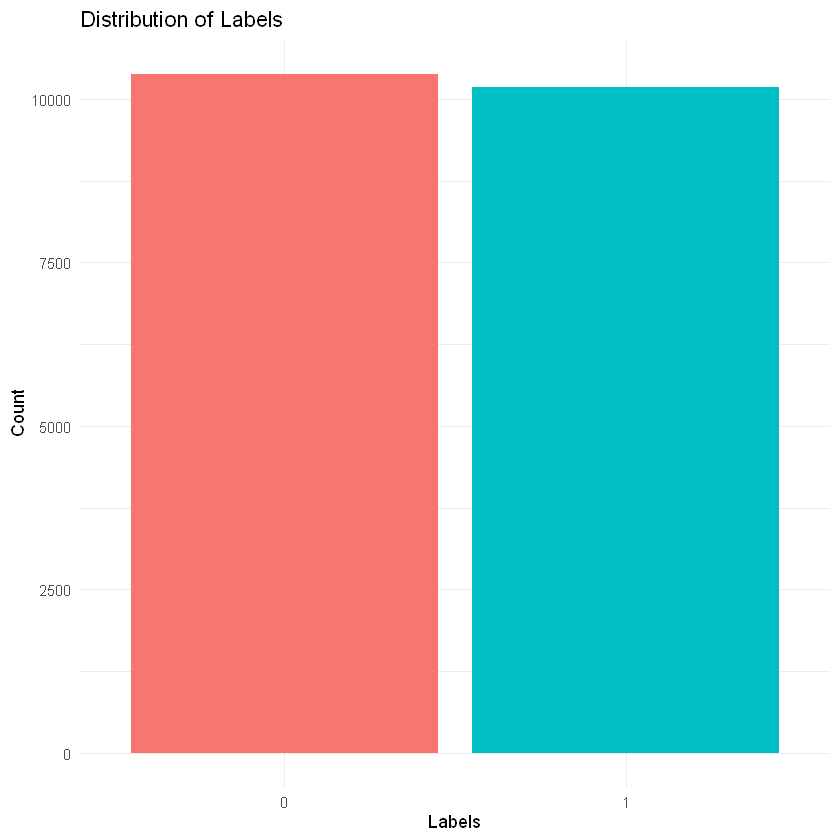

In [21]:
# Print number of elements
cat("Total number of elements:", nrow(dataset), "\n")

mean_words <- mean(str_count(as.character(dataset$Text), boundary("word")), na.rm = TRUE)
cat("Mean length of Text (in words):", round(mean_words, 2), "\n")

dataset$Label <- factor(trimws(as.character(dataset$Label)))

# Plot with as many colors as unique labels
num_labels <- length(levels(dataset$Label))
palette <- scales::hue_pal()(num_labels)

ggplot(dataset, aes(x = Label, fill = Label)) +
  geom_bar() +
  scale_fill_manual(values = palette) +
  labs(title = "Distribution of Labels",
       x = "Labels",
       y = "Count") +
  theme_minimal() +
  theme(legend.position="none")

In [26]:
# Training
model <- TrainMultinomialNB(train$Text, train$Label, labels, laplace = 1, ngram = 3, threshold = 5e-05)

# Testing on validation set
predicted <- PredictMultinomialNB(model, validation$Text, labels)

# Performance evaluation
true <- sapply(validation$Label, function(x) split(x, ",")[[1]][1])  # prende solo la prima etichetta
accuracy <- sum(predicted == true) / length(true)
print(paste("Accuracy:", round(accuracy * 100, 2), "%"))

[1] "Accuracy: 51.66 %"


In [ ]:
EvaluateBinaryClassification(true, predicted, positive_label = "1")

Accuracy: 86.05%

Confusion Matrix (binary):
         Actual
Predicted    0    1
        0 1876  345
        1  229 1665

Precision (positive = 1): 0.879
Recall    (positive = 1): 0.828
F1 score  (positive = 1): 0.853


### Hyperparameter tuning

In [ ]:
tune_out <- TuneMultinomialNB(
  texts          = dataset$Text,
  label          = dataset$Label,
  tags           = labels,
  laplace_grid   = c(0.5, 1),
  ngram_grid     = c(1, 2, 3),
  threshold_grid = c(1e-06, 1e-05, 5e-05),    # 0 = keep all tokens
  test_ratio     = 0.2,     # 20% for test
  seed           = 123      # for reproducibility
)

tune_out$cv_table    # accuracy for each hyperparameter combination
tune_out$best_grid   # best laplace, ngram, threshold and test accuracy
model_final <- tune_out$final_model

## Project Summary – Naive Bayes Classifier for Fake News Detection

During this project we worked at designing a Naive Bayes classifier. After importing and initially preprocessing the dataset—tokenization, lemmatization, and elimination of stop‑words—we defined the algorithm. 

Besides the basic features of a Multinomial Bayes classifier, we added:
- Laplace smoothing (additive smoothing), allowing the user to choose the smoothing factor to deal with vocabs that are not in the training;
- N‑grams, which consider an ensemble of consecutive words instead of individual ones to better capture sentence meaning.

For the second, more complex dataset, we introduced a custom vocabulary reduction function, allowing the user to:
- Keep a chosen percentage of the original vocabulary, or
- Include only tokens above a minimum frequency threshold.

This helped reduce computational complexity.  
The algorithm was then tested on two different datasets, with various parameters fine‑tuned using grid search and k‑fold validation.

---

## Discussion

### First Dataset Results

For the first dataset we used only unigrams, as the text snippets were too short and using N‑grams would have led to sparsity.  
We tested different Laplace smoothing factors, and the best accuracy reached approximately **23.63 %**, slightly above random guessing.

We then experimented with binary classification:
- First, we merged the “truish” and “falsish” labels to form a new binary target → Accuracy: **57 %**
- Then, we restricted the data to samples labeled strictly *True* or *False* → Accuracy: **59 %**

---

### Performance Limitations

The modest performance can be explained by three key factors:

1. Very short documents – Most posts contain only a few tokens, so class‑conditional estimates are extremely sparse.  
2. Label noise and overlap – Labels such as *Half‑True*, *Mostly‑True*, and *Barely‑True* share much of the same vocabulary, giving the classifier little discriminative power.  
3. Naive independence assumption – Multinomial Naive Bayes treats every token (or N‑gram) as conditionally independent given the class, an assumption that breaks down in political language where phrases and framing matter.


Multinomial Naive Bayes assumes that words are conditionally independent given the class, meaning it treats each word as unrelated to the others. This is a strong and often unrealistic assumption for natural language. In fake news detection, word combinations, tone, and context carry crucial meaning (e.g., “not true” vs. “true”), and Naive Bayes cannot capture such dependencies. As a result, it struggles with the nuanced language and overlapping vocabulary typical of fake news texts.

We suggest as an improvement, besides extending and carefully prepocessing the dataset, a "non Markovian" approach to the network, where words are not independent one another. Rather than that, especially on the web, sentences and words have specific structures and 'rules'. Because of this, it can be very important to incorporate in our prior knowledge all these little particulars that define reliable and unreliable news, such as the author, the platform it was posted on, as well as the language of course.